# Image Preprocessing Methods in Computer Vision and Medical Imaging

This notebook introduces common image preprocessing methods used before segmentation, classification, detection, registration, or measurement tasks.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

def show_gray(img, title="Image"):
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_color(img, title="Image"):
    plt.figure()
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def compare_images(images, titles, cmap="gray", cols=3, figsize=(16, 10)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if len(img.shape) == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_histogram(img, title="Histogram"):
    plt.figure(figsize=(7, 4))
    plt.hist(img.ravel(), bins=256, range=[0, 256])
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

## Step 1: Load an Example Image
Use your own image if you want.  
Update the file path below.


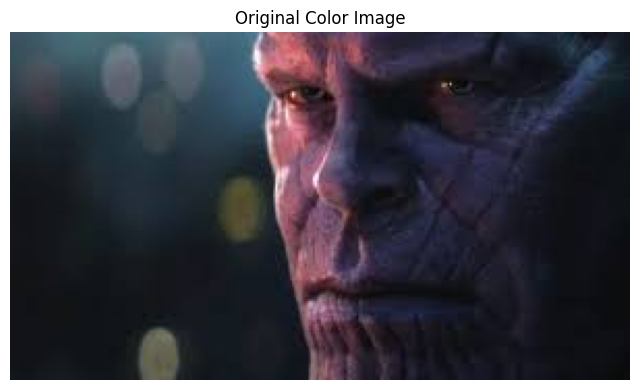

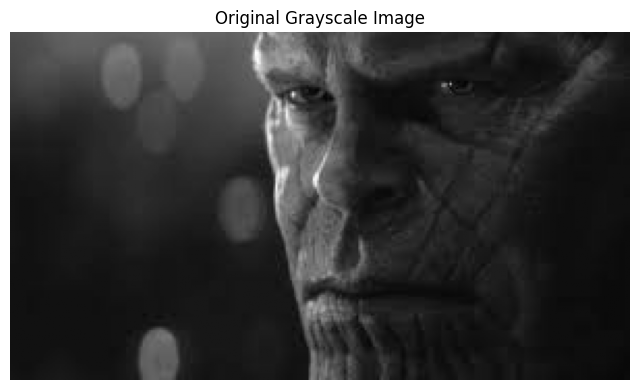

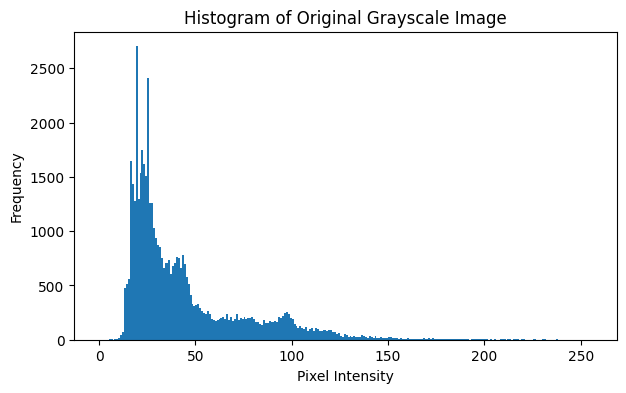

In [3]:
# Replace with your image path
image_path = "/content/drive/MyDrive/images.jpeg"

img_color = cv2.imread(image_path)

if img_color is None:
    print("Image not found. Please place an image in the same folder and name it 'sample_image.jpg', or change the path.")
else:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    show_color(img_color, "Original Color Image")
    show_gray(img_gray, "Original Grayscale Image")
    plot_histogram(img_gray, "Histogram of Original Grayscale Image")

## 1. Resizing

Images in datasets often have different sizes. Many machine learning and deep learning pipelines require a fixed input size.

### Common interpolation methods

- `INTER_NEAREST`: fastest, but can look blocky
- `INTER_LINEAR`: common default
- `INTER_CUBIC`: smoother, often better for enlarging
- `INTER_AREA`: often good for shrinking

### Why it matters

Resizing changes:

- image resolution
- visible detail
- edge sharpness
- computational cost

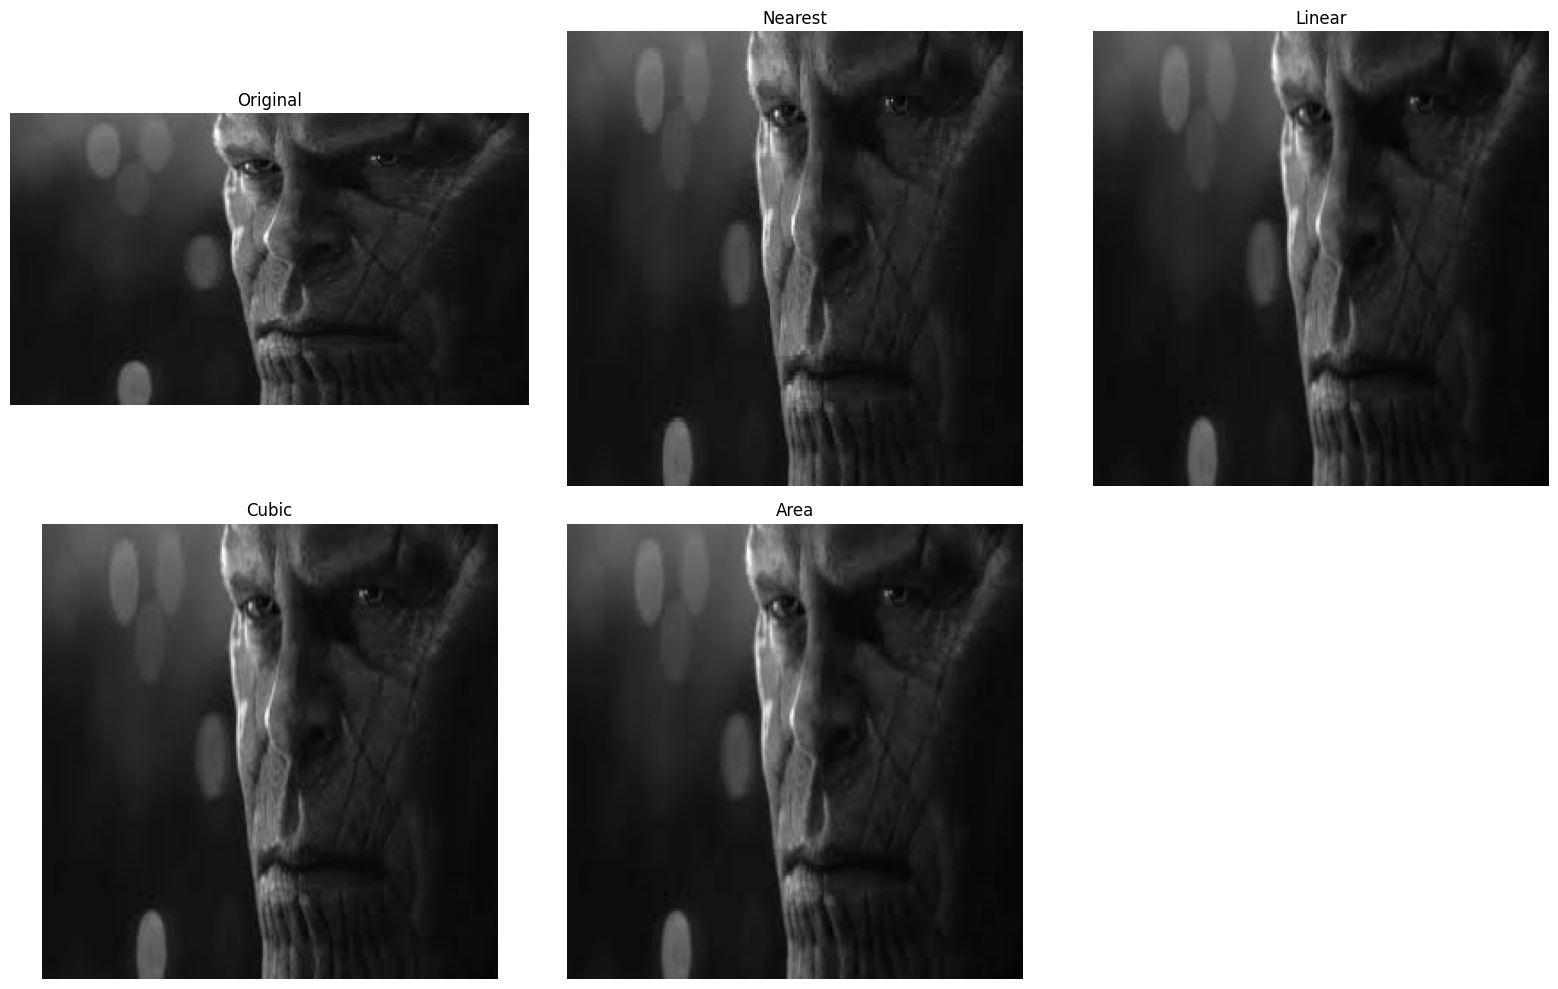

In [4]:
if img_color is not None:
    resized_nearest = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_NEAREST)
    resized_linear = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_LINEAR)
    resized_cubic = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_CUBIC)
    resized_area = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_AREA)

    compare_images(
        [img_gray, resized_nearest, resized_linear, resized_cubic, resized_area],
        ["Original", "Nearest", "Linear", "Cubic", "Area"],
        cols=3
    )

Original min/max: 2.0 252.0
Min-max normalized min/max: 0.0 1.0
Standardized mean/std: -1.0935587e-08 1.0


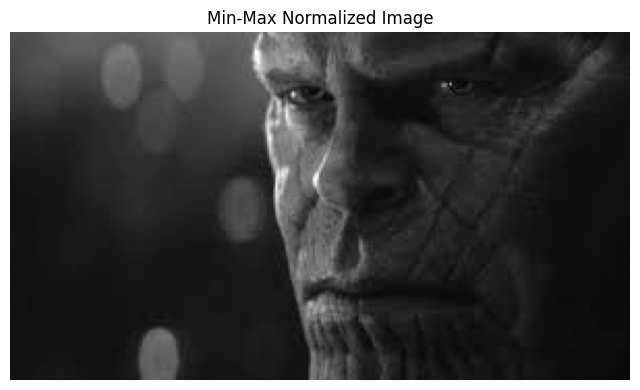

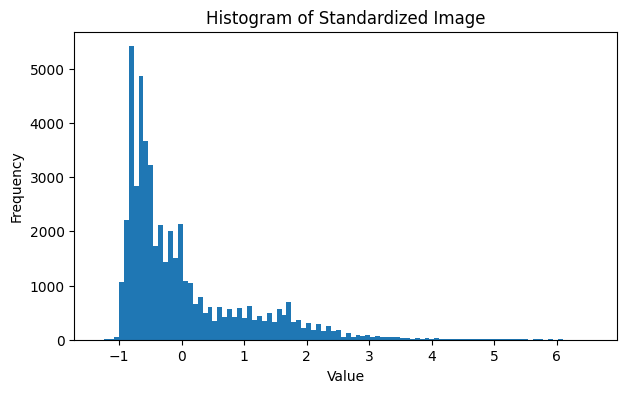

In [5]:
if img_color is not None:
    img_float = img_gray.astype(np.float32)

    minmax = (img_float - img_float.min()) / (img_float.max() - img_float.min() + 1e-8)
    standardized = (img_float - img_float.mean()) / (img_float.std() + 1e-8)

    print("Original min/max:", img_float.min(), img_float.max())
    print("Min-max normalized min/max:", minmax.min(), minmax.max())
    print("Standardized mean/std:", standardized.mean(), standardized.std())

    show_gray(minmax, "Min-Max Normalized Image")
    plt.figure(figsize=(7,4))
    plt.hist(standardized.ravel(), bins=100)
    plt.title("Histogram of Standardized Image")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

### Task 2
Implement min-max normalization manually without using a ready-made function.

### Challenge 2
Why is standardization often used for deep learning, while histogram equalization is often used for visual enhancement?

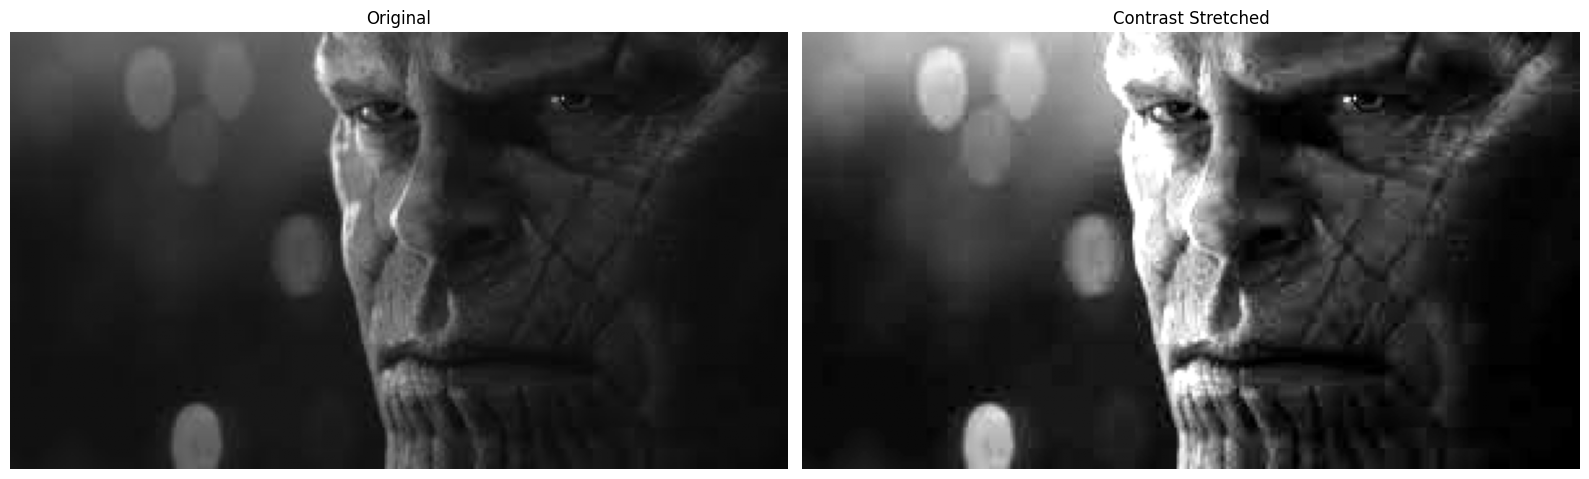

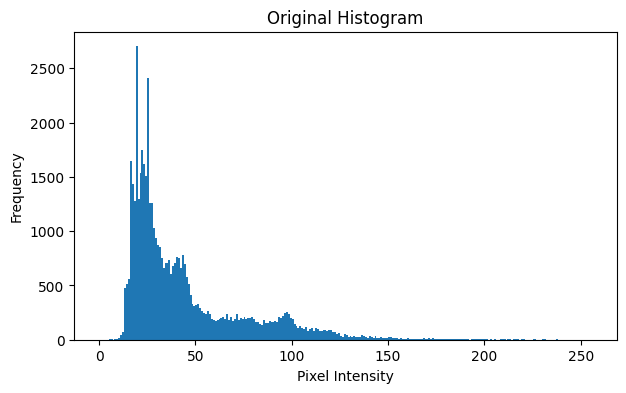

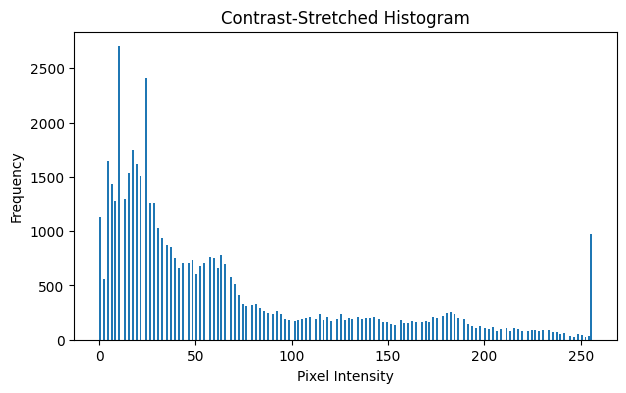

In [6]:
if img_color is not None:
    p2, p98 = np.percentile(img_gray, (2, 98))
    stretched = np.clip((img_gray - p2) * 255.0 / (p98 - p2 + 1e-8), 0, 255).astype(np.uint8)

    compare_images([img_gray, stretched], ["Original", "Contrast Stretched"], cols=2)
    plot_histogram(img_gray, "Original Histogram")
    plot_histogram(stretched, "Contrast-Stretched Histogram")

## 4. Histogram Equalization

Histogram equalization redistributes pixel intensities so that the histogram becomes more spread out.

This often improves global contrast.

### Advantages

- simple
- fast
- improves low-contrast images

### Limitations

- may over-enhance noise
- may make some regions look unnatural
- not always good for non-uniform lighting

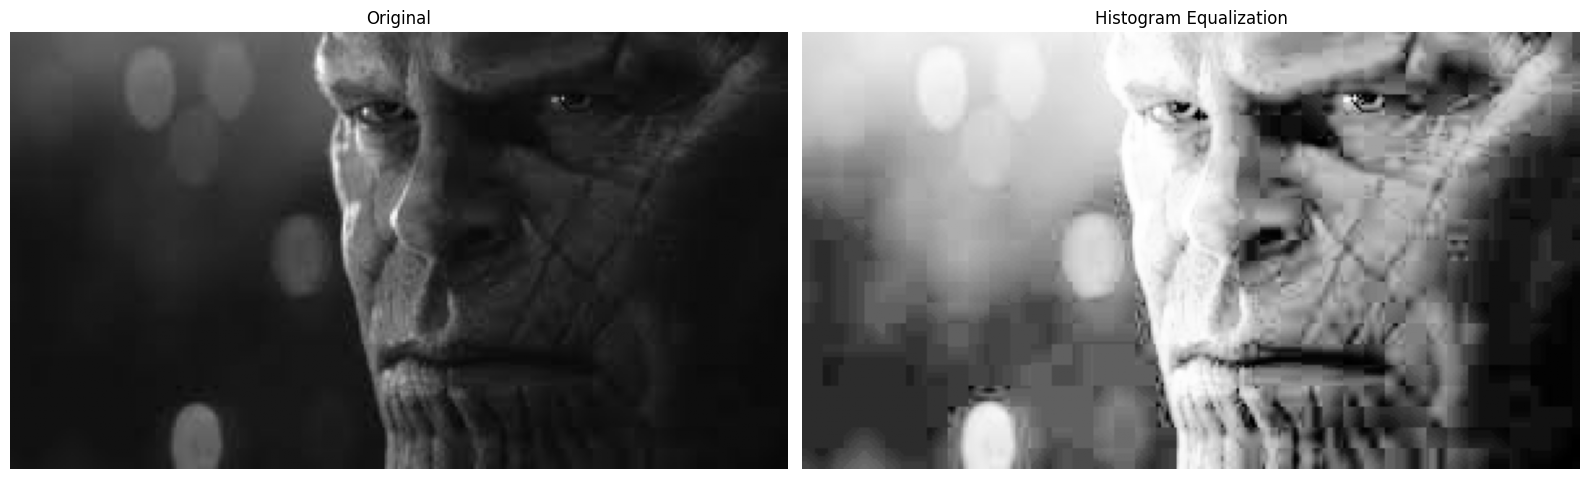

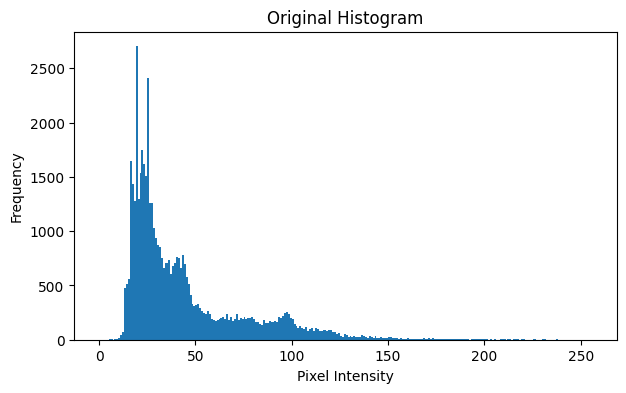

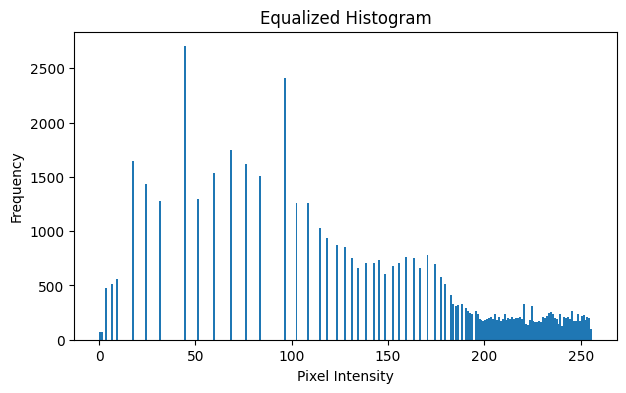

In [7]:
if img_color is not None:
    hist_eq = cv2.equalizeHist(img_gray)

    compare_images([img_gray, hist_eq], ["Original", "Histogram Equalization"], cols=2)
    plot_histogram(img_gray, "Original Histogram")
    plot_histogram(hist_eq, "Equalized Histogram")

## 5. CLAHE (Contrast Limited Adaptive Histogram Equalization)

**CLAHE** improves local contrast instead of only global contrast.

It works by:

1. dividing the image into small tiles
2. applying histogram equalization inside each tile
3. limiting contrast amplification to reduce noise boosting
4. combining the tiles smoothly

This is especially useful for:

- medical images
- X-rays
- retinal images
- low-contrast local structures

### Important parameters

- `clipLimit`: limits over-amplification
- `tileGridSize`: size of local regions

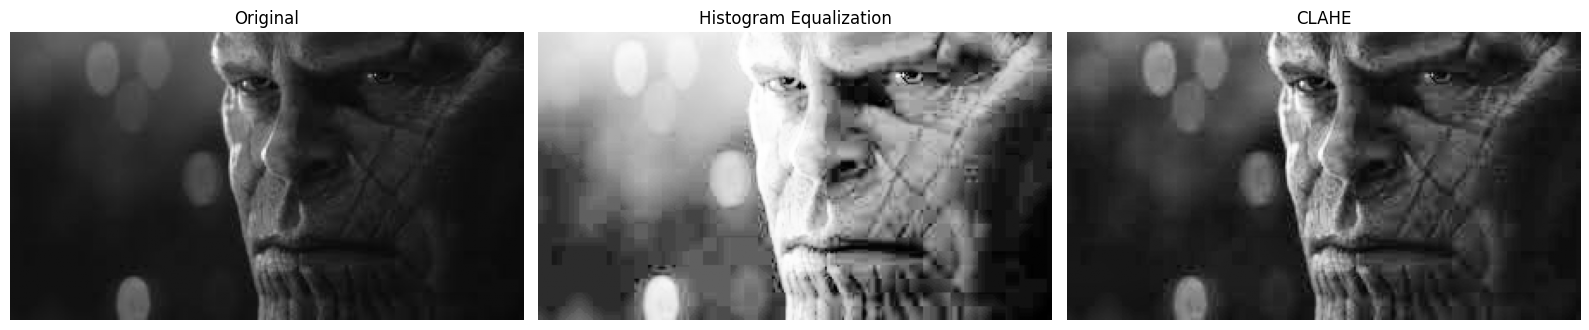

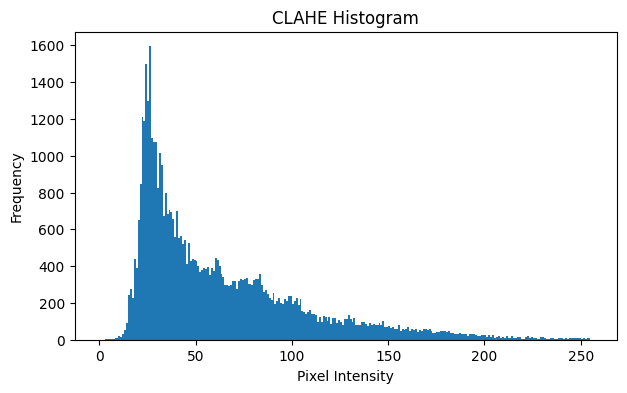

In [8]:
if img_color is not None:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)

    compare_images(
        [img_gray, hist_eq, img_clahe],
        ["Original", "Histogram Equalization", "CLAHE"],
        cols=3
    )
    plot_histogram(img_clahe, "CLAHE Histogram")

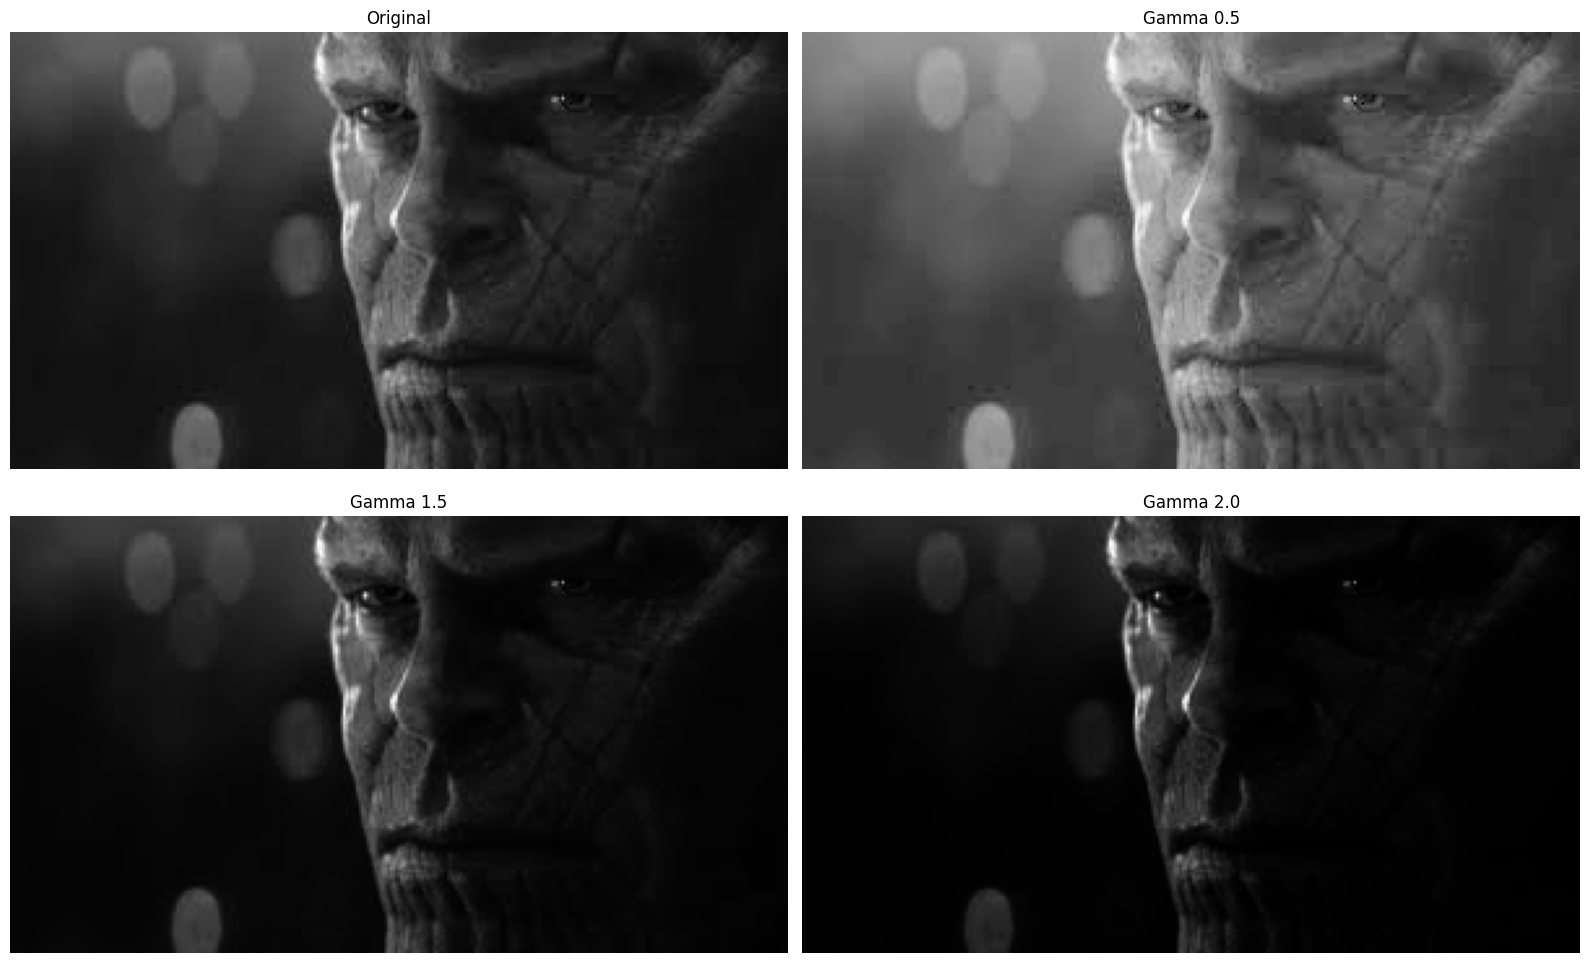

In [9]:
if img_color is not None:
    def gamma_correction(image, gamma=1.0):
        image_norm = image / 255.0
        corrected = np.power(image_norm, gamma)
        corrected = np.clip(corrected * 255, 0, 255).astype(np.uint8)
        return corrected

    gamma_05 = gamma_correction(img_gray, gamma=0.5)
    gamma_15 = gamma_correction(img_gray, gamma=1.5)
    gamma_20 = gamma_correction(img_gray, gamma=2.0)

    compare_images(
        [img_gray, gamma_05, gamma_15, gamma_20],
        ["Original", "Gamma 0.5", "Gamma 1.5", "Gamma 2.0"],
        cols=2
    )

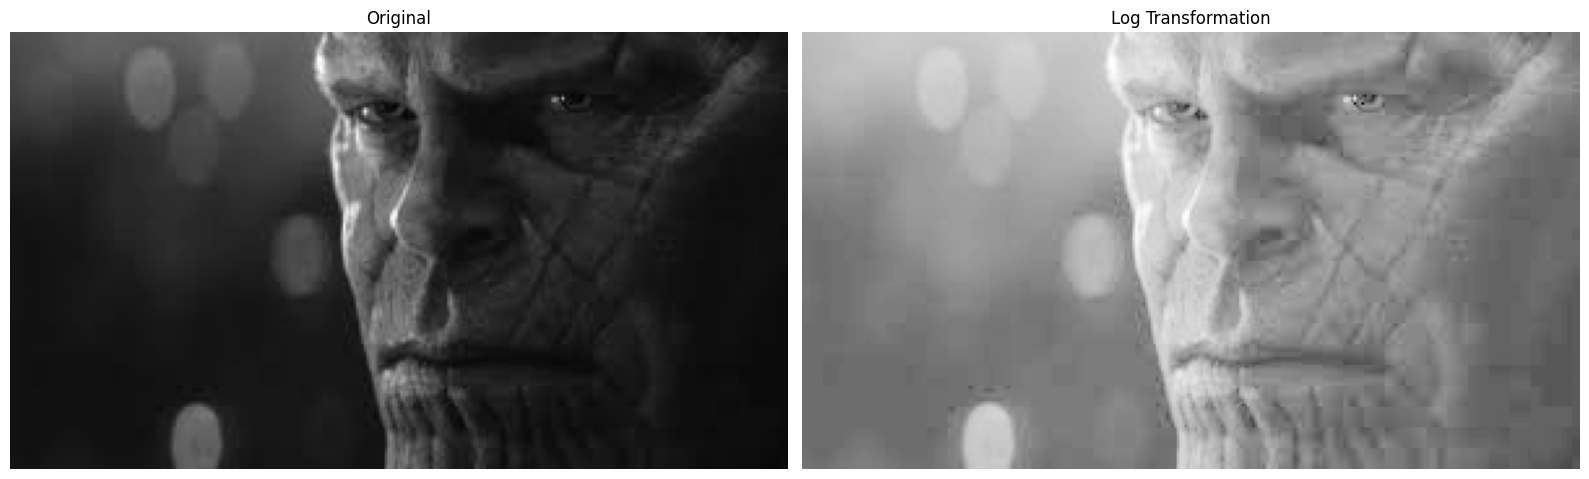

In [10]:
if img_color is not None:
    img_float = img_gray.astype(np.float32)
    c = 255 / np.log(1 + np.max(img_float))
    log_img = c * np.log(1 + img_float)
    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    compare_images([img_gray, log_img], ["Original", "Log Transformation"], cols=2)